# Domestic Metadata And CLIP Analysis

Notebook liczy tylko analizę gotowych danych: JS dla oczekiwanych relacji A->B, pełne directed JS do appendixa, rozkłady metadata oraz analogiczną analizę CLIP, jeśli plik CLIP istnieje.

In [1]:
from pathlib import Path
import sys

import pandas as pd


def _find_repo_root(start: Path = Path.cwd()) -> Path:
    candidates = [start, *start.parents, start / "cgsid"]
    for candidate in candidates:
        if (candidate / "src" / "cgsid").exists():
            return candidate
    raise FileNotFoundError("Could not find the cgsid repository root")


ROOT = _find_repo_root()
sys.path.insert(0, str(ROOT / "src"))

from cgsid.analysis.tools import (
    RelationSpec,
    all_directed_js,
    build_clip_metadata_from_mappings,
    clip_accuracy_by_label,
    expected_relation_table,
    format_clip_accuracy_table,
    plot_value_distributions,
    print_relation_tabs,
    value_distribution_table,
)
from cgsid.core.config import Settings

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)


In [2]:
DATASET = "domestic"
DATASET_DIR = Settings().dataset_dir(DATASET)
METADATA_PATH = DATASET_DIR / "metadata.csv"
CLIP_PATH = DATASET_DIR / "clip_scores.csv"
COLUMNS = ["object_1", "object_1_color", "pose", "environment", "day_time", "object_2", "object_2_color"]
EXPECTED_RELATIONS: list[RelationSpec] = [
    ("animal -> room", "object_1", "environment"),
    ("room -> ball presence", "environment", "object_2"),
    ("ball presence -> animal", "object_2", "object_1"),
]


## Metadata

In [3]:
metadata_path = METADATA_PATH
if not metadata_path.exists():
    raise FileNotFoundError(f'Metadata file not found: {metadata_path}')
metadata = pd.read_csv(metadata_path).copy()
print(f'metadata: {metadata_path} rows={len(metadata)}')
metadata[COLUMNS].head()


metadata: /mnt/evafs/groups/mi2lab/ljaremek/cgsid_tmp/domestic_correlated/metadata.csv rows=100


,object_1,object_1_color,pose,environment,day_time,object_2,object_2_color
0,dog,dark,lying,living_room,day,ball,red
1,dog,dark,lying,living_room,day,ball,red
2,dog,dark,lying,living_room,day,ball,red
3,dog,dark,lying,living_room,day,ball,red
4,dog,dark,lying,living_room,day,ball,red


## Metadata Distributions

,dataset,column,column_label,value,value_label,count,proportion
0,metadata,object_1,Animal,dog,dog,100,1.00
1,metadata,object_1_color,Color,dark,dark,100,1.00
2,metadata,pose,Pose,lying,lying,100,1.00
3,metadata,environment,Environment,living_room,living room,100,1.00
4,metadata,day_time,Time of day,evening,evening,22,0.22
5,metadata,day_time,Time of day,day,day,78,0.78
6,metadata,object_2,Second object,ball,ball,100,1.00
7,metadata,object_2_color,Second object color,green,green,13,0.13
8,metadata,object_2_color,Second object color,blue,blue,13,0.13
9,metadata,object_2_color,Second object color,orange,orange,13,0.13


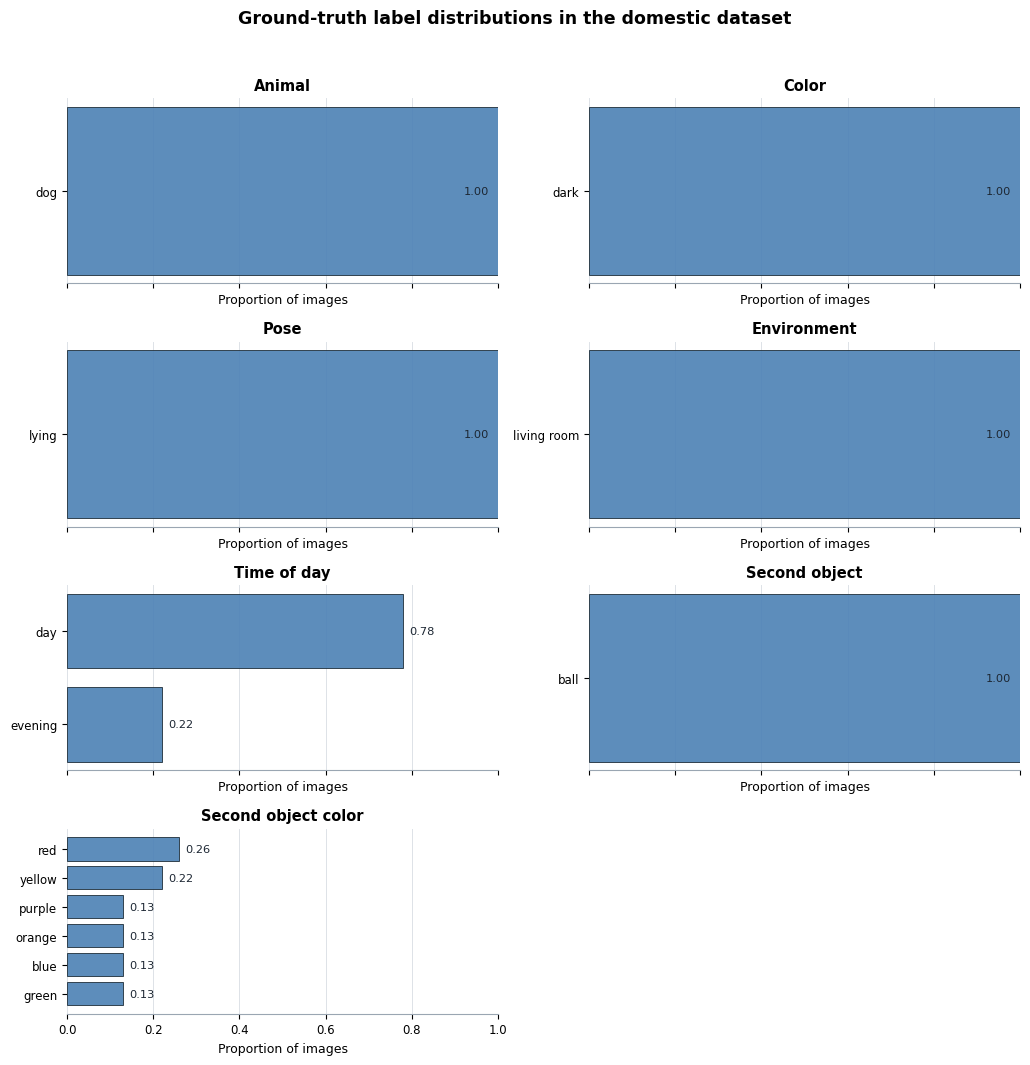

In [4]:
metadata_value_distributions = value_distribution_table(metadata[COLUMNS], "metadata")
display(metadata_value_distributions)

plot_value_distributions(
    metadata[COLUMNS],
    f"Ground-truth label distributions in the {DATASET} dataset",
    color="#4f83b6",
)


## Metadata Expected JS

In [5]:
metadata_expected_js = expected_relation_table(metadata, EXPECTED_RELATIONS)
display(metadata_expected_js)
print_relation_tabs(metadata, EXPECTED_RELATIONS)

,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value,reverse_weighted_js
0,animal -> room,object_1,environment,0.0,0.0,dog,0.0
1,room -> ball presence,environment,object_2,0.0,0.0,living_room,0.0
2,ball presence -> animal,object_2,object_1,0.0,0.0,ball,0.0



=== animal -> room: object_1 -> environment ===


environment,living_room
object_1,
dog,1.0



=== room -> ball presence: environment -> object_2 ===


object_2,ball
environment,
living_room,1.0



=== ball presence -> animal: object_2 -> object_1 ===


object_1,dog
object_2,
ball,1.0


## Metadata Full JS For Appendix

In [6]:
metadata_full_js = all_directed_js(metadata, COLUMNS)
display(metadata_full_js)


,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value
0,day_time -> object_2_color,day_time,object_2_color,0.085245,0.328481,evening
1,object_2_color -> day_time,object_2_color,day_time,0.085245,0.119832,blue
2,object_1 -> object_1_color,object_1,object_1_color,0.000000,0.000000,dog
3,object_2 -> object_1_color,object_2,object_1_color,0.000000,0.000000,ball
4,environment -> object_2_color,environment,object_2_color,0.000000,0.000000,living_room
5,day_time -> object_1,day_time,object_1,0.000000,0.000000,day
6,day_time -> object_1_color,day_time,object_1_color,0.000000,0.000000,day
7,day_time -> pose,day_time,pose,0.000000,0.000000,day
8,day_time -> environment,day_time,environment,0.000000,0.000000,day
9,day_time -> object_2,day_time,object_2,0.000000,0.000000,day


## CLIP

In [7]:
CLIP_MAPPINGS: dict[str, dict[str, str]] = {
    "object_1": {
        "dog": "pet_animal_dog",
        "cat": "pet_animal_cat",
    },
    "object_1_color": {
        "dark": "contains_color_dark",
        "brown": "contains_color_brown",
        "white": "contains_color_white",
        "ginger": "contains_color_ginger",
        "gray": "contains_color_gray",
    },
    "pose": {
        "lying": "pet_position_lying",
        "standing": "pet_position_standing",
    },
    "environment": {
        "living_room": "pet_room_living_room",
        "kitchen": "pet_room_kitchen",
    },
    "day_time": {
        "day": "pet_time_day",
        "evening": "pet_time_evening",
    },
    "object_2": {
        "ball": "pet_state_playing_with_ball",
        "none": "pet_state_not_playing_with_ball",
    },
    "object_2_color": {
        "red": "contains_ball_color_red",
        "yellow": "contains_ball_color_yellow",
        "green": "contains_ball_color_green",
        "blue": "contains_ball_color_blue",
        "orange": "contains_ball_color_orange",
        "purple": "contains_ball_color_purple",
    },
}


def build_clip_metadata(clip: pd.DataFrame) -> pd.DataFrame:
    pred = build_clip_metadata_from_mappings(clip, CLIP_MAPPINGS)
    pred.loc[pred["object_2"] == "none", "object_2_color"] = "none"
    return pred


In [8]:
clip_path = CLIP_PATH
if not clip_path.exists():
    clip = None
    print(f'clip: no file found at {clip_path}')
    print('No CLIP results found yet. Run 2_query_dataset_with_clip_domestic.py, then rerun from this cell.')
else:
    clip = pd.read_csv(clip_path)
    print(f'clip: {clip_path} rows={len(clip)}')
    clip_pred = build_clip_metadata(clip)
    display(clip_pred[COLUMNS].head())


clip: /mnt/evafs/groups/mi2lab/ljaremek/cgsid_tmp/domestic_correlated/clip_scores.csv rows=100


,object_1,object_1_color,pose,environment,day_time,object_2,object_2_color
0,dog,dark,standing,living_room,day,ball,red
1,dog,dark,lying,living_room,day,ball,red
2,dog,dark,lying,living_room,day,ball,red
3,dog,dark,lying,living_room,day,ball,red
4,dog,dark,standing,living_room,day,ball,red


## CLIP Distributions

,dataset,column,column_label,value,value_label,count,proportion
0,clip,object_1,Animal,dog,dog,100,1.00
1,clip,object_1_color,Color,gray,gray,3,0.03
2,clip,object_1_color,Color,dark,dark,97,0.97
3,clip,pose,Pose,standing,standing,22,0.22
4,clip,pose,Pose,lying,lying,78,0.78
5,clip,environment,Environment,living_room,living room,100,1.00
6,clip,day_time,Time of day,evening,evening,9,0.09
7,clip,day_time,Time of day,day,day,91,0.91
8,clip,object_2,Second object,none,none,1,0.01
9,clip,object_2,Second object,ball,ball,99,0.99


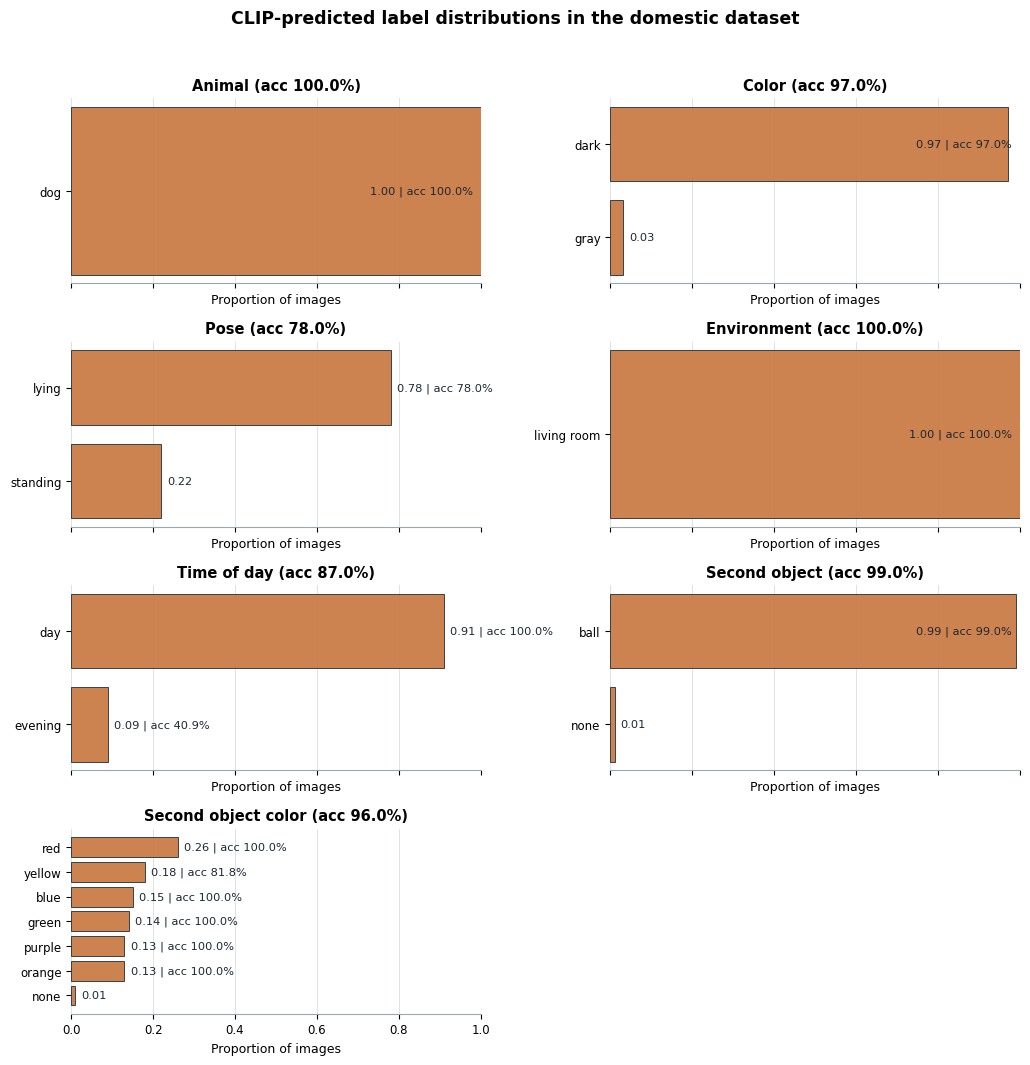

In [9]:
if clip is not None:
    clip_value_distributions = value_distribution_table(clip_pred[COLUMNS], "clip")
    display(clip_value_distributions)
    clip_accuracy_suffixes = {
        column: f"acc {100 * metadata[column].reset_index(drop=True).eq(clip_pred[column].reset_index(drop=True)).mean():.1f}%"
        for column in COLUMNS
    }
    clip_label_accuracy_suffixes = {}
    for column in COLUMNS:
        truth = metadata[column].reset_index(drop=True)
        pred = clip_pred[column].reset_index(drop=True)
        correct = truth.eq(pred)
        for value in sorted(truth.dropna().unique(), key=str):
            mask = truth.eq(value)
            if mask.any():
                clip_label_accuracy_suffixes[(column, value)] = f"acc {100 * correct[mask].mean():.1f}%"

    plot_value_distributions(
        clip_pred[COLUMNS],
        f"CLIP-predicted label distributions in the {DATASET} dataset",
        color="#c87941",
        title_suffixes=clip_accuracy_suffixes,
        value_suffixes=clip_label_accuracy_suffixes,
    )


## CLIP Expected JS

In [10]:
if clip is not None:
    clip_expected_js = expected_relation_table(clip_pred, EXPECTED_RELATIONS)
    display(clip_expected_js)
    print_relation_tabs(clip_pred, EXPECTED_RELATIONS)

,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value,reverse_weighted_js
0,animal -> room,object_1,environment,0.0,0.0,dog,0.0
1,room -> ball presence,environment,object_2,0.0,0.0,living_room,0.0
2,ball presence -> animal,object_2,object_1,0.0,0.0,ball,0.0



=== animal -> room: object_1 -> environment ===


environment,living_room
object_1,
dog,1.0



=== room -> ball presence: environment -> object_2 ===


object_2,ball,none
environment,,
living_room,0.99,0.01



=== ball presence -> animal: object_2 -> object_1 ===


object_1,dog
object_2,
ball,1.0
none,1.0


## CLIP Full JS For Appendix

In [11]:
if clip is not None:
    clip_full_js = all_directed_js(clip_pred, COLUMNS)
    display(clip_full_js)


,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value
0,object_2_color -> day_time,object_2_color,day_time,0.036830,0.046530,blue
1,day_time -> object_2_color,day_time,object_2_color,0.036830,0.379088,evening
2,pose -> object_2_color,pose,object_2_color,0.019306,0.078530,standing
3,object_2_color -> pose,object_2_color,pose,0.019306,0.119832,none
4,object_2_color -> object_1_color,object_2_color,object_1_color,0.015234,0.031403,green
5,object_1_color -> object_2_color,object_1_color,object_2_color,0.015234,0.491580,gray
6,object_2 -> object_2_color,object_2,object_2_color,0.014563,0.959531,none
7,object_2_color -> object_2,object_2_color,object_2,0.014563,0.959531,none
8,day_time -> object_1_color,day_time,object_1_color,0.001412,0.015165,evening
9,object_1_color -> day_time,object_1_color,day_time,0.001412,0.046530,gray


## Metadata vs CLIP Summary

In [12]:
if clip is not None:
    comparison = metadata_expected_js.merge(clip_expected_js, on=['relation', 'condition_column', 'target_column'], suffixes=('_metadata', '_clip'))
    comparison['weighted_js_delta_metadata_minus_clip'] = comparison['weighted_js_metadata'] - comparison['weighted_js_clip']
    display(comparison)

    wjs_comparison = metadata_full_js.merge(clip_full_js, on=['relation', 'condition_column', 'target_column'], suffixes=('_metadata', '_clip'))
    wjs_summary = wjs_comparison[['relation', 'weighted_js_metadata', 'weighted_js_clip']].rename(columns={
        'weighted_js_metadata': 'wjs (raw)',
        'weighted_js_clip': 'wjs (clip)',
    })
    wjs_summary = (
        wjs_summary
        .assign(_raw_sort=wjs_summary['wjs (raw)'].round(6), _clip_sort=wjs_summary['wjs (clip)'].round(6))
        .sort_values(['_raw_sort', '_clip_sort'], ascending=False)
        .drop(columns=['_raw_sort', '_clip_sort'])
        .reset_index(drop=True)
    )
    display(wjs_summary.style.format({'wjs (raw)': '{:.6f}', 'wjs (clip)': '{:.6f}'}))

,relation,condition_column,target_column,weighted_js_metadata,max_js_metadata,strongest_condition_value_metadata,reverse_weighted_js_metadata,weighted_js_clip,max_js_clip,strongest_condition_value_clip,reverse_weighted_js_clip,weighted_js_delta_metadata_minus_clip
0,animal -> room,object_1,environment,0.0,0.0,dog,0.0,0.0,0.0,dog,0.0,0.0
1,room -> ball presence,environment,object_2,0.0,0.0,living_room,0.0,0.0,0.0,living_room,0.0,0.0
2,ball presence -> animal,object_2,object_1,0.0,0.0,ball,0.0,0.0,0.0,ball,0.0,0.0


,relation,wjs (raw),wjs (clip)
0,day_time -> object_2_color,0.085245,0.036830
1,object_2_color -> day_time,0.085245,0.036830
2,object_2_color -> pose,0.000000,0.019306
3,pose -> object_2_color,0.000000,0.019306
4,object_2_color -> object_1_color,0.000000,0.015234
5,object_1_color -> object_2_color,0.000000,0.015234
6,object_2 -> object_2_color,0.000000,0.014563
7,object_2_color -> object_2,0.000000,0.014563
8,day_time -> object_1_color,0.000000,0.001412
9,object_1_color -> day_time,0.000000,0.001412
